## 1. Setup

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [2]:
try:
    X_train = joblib.load("X_train.pkl")
    X_test = joblib.load("X_test.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test :", X_test.shape, "y_test :", y_test.shape)

Loaded successfully
X_train: (3996, 42) y_train: (3996,)
X_test : (1000, 42) y_test : (1000,)


## 2. Baseline Model 
untuned KNN model, 
`n_neighbors=15` chosen arbitrarily

In [3]:
# create, train, and evaluate a baseline model
knn = KNeighborsClassifier(n_neighbors=15, weights='uniform')
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("Baseline Accuracy:", knn_accuracy)
print(classification_report(y_test, knn_pred))

Baseline Accuracy: 0.777
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       438
           1       0.79      0.82      0.80       562

    accuracy                           0.78      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.78      0.78      0.78      1000



## 3. Hyperparameter Tuning 
Grid Search is used to find the best `n_neighbors` and `metric`. `weights` is fixed to `'uniform'` throughout — this avoids the self-matching effect of `'distance'` weighting, where a training point ends up voting for itself with near-total weight (since its distance to itself is 0), which otherwise inflates training accuracy independently of true model quality.

In [4]:
param_grid = {
    "n_neighbors": range(1, 61),
    "weights": ["uniform"],
    "metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_knn = grid_search.best_estimator_

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best Cross-Validated Accuracy: 0.8151


## 4. Best Model Evaluation
The tuned model is evaluated on the test set, including a confusion matrix and a training-vs-testing accuracy comparison to check for overfitting.

In [5]:
best_pred = best_knn.predict(X_test)

train_accuracy = best_knn.score(X_train, y_train)
test_accuracy = best_knn.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print()
print(classification_report(y_test, best_pred))

Training Accuracy: 0.9061561561561562
Testing Accuracy: 0.807

              precision    recall  f1-score   support

           0       0.79      0.76      0.78       438
           1       0.82      0.84      0.83       562

    accuracy                           0.81      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.81      0.81      0.81      1000



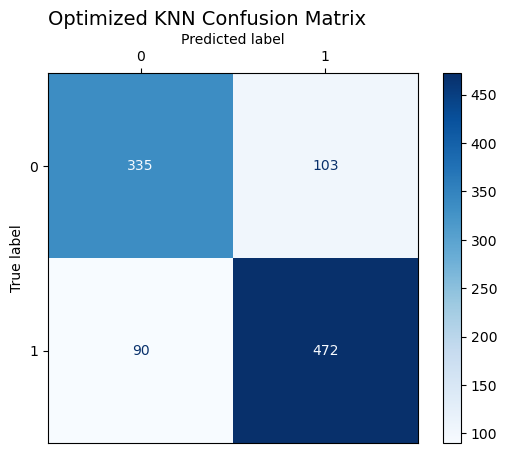

In [6]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.title("Optimized KNN Confusion Matrix", fontsize=14, loc='left')
plt.xlabel("Predicted label", fontsize=10)
plt.ylabel("True label", fontsize=10)

plt.show()

## 5. Model Stability — Cross-Validation & Accuracy vs. K 
5-fold cross-validation checks how consistent the model's accuracy is across different subsets of the training data. The Accuracy vs. K plot confirms the chosen `n_neighbors` sits at, or near, a genuine peak, using `weights='uniform'` throughout to match the final model.

Fold scores: [0.8175     0.82603254 0.81602003 0.8135169  0.80225282]
Average CV Accuracy: 0.8150644555694619


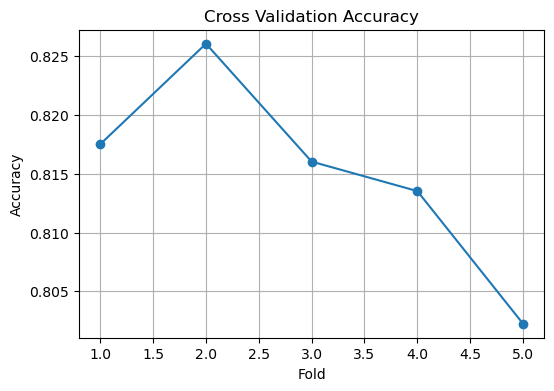

In [7]:
cv_scores = cross_val_score(best_knn, X_train, y_train, cv=5, scoring="accuracy")

print("Fold scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

plt.figure(figsize=(6, 4))
plt.plot(range(1, 6), cv_scores, marker="o")
plt.title("Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

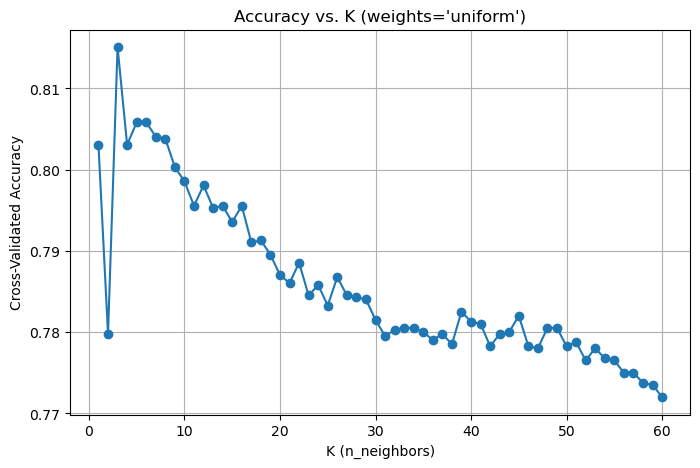

In [8]:
best_metric = grid_search.best_params_["metric"]

k_range = range(1, 61)
k_scores = []

for k in k_range:
    temp_knn = KNeighborsClassifier(n_neighbors=k, weights="uniform", metric=best_metric)
    scores = cross_val_score(temp_knn, X_train, y_train, cv=5, scoring="accuracy")
    k_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(k_range, k_scores, marker="o")
plt.title("Accuracy vs. K (weights='uniform')")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

## 6. Decision Threshold Optimization (Youden's J Statistic) 
Rather than relying on the default 0.5 probability cutoff, this finds the threshold that maximizes **Youden's J = Sensitivity + Specificity − 1**, using the ROC curve. This is a formula distinct from accuracy/precision/recall/F1, and can improve overall classification accuracy by shifting the decision boundary to better suit the data's true positive/negative trade-off.

In [9]:
y_probs = best_knn.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
j_scores = tpr - fpr
best_threshold_idx = np.argmax(j_scores)
best_threshold = thresholds[best_threshold_idx]

y_pred_optimal = (y_probs >= best_threshold).astype(int)

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
print()
print("Accuracy with optimal threshold:", accuracy_score(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

Optimal threshold: 0.6667
Youden's J at this threshold: 0.6047

Accuracy with optimal threshold: 0.807
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       438
           1       0.82      0.84      0.83       562

    accuracy                           0.81      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.81      0.81      0.81      1000



## 6.2 Gaussian Weighted Voting

In [12]:
def gaussian_weights(distances, sigma=1.0):
    return np.exp(-(distances**2) / (2 * sigma**2))

knn_gaussian = KNeighborsClassifier(n_neighbors=15, weights=gaussian_weights)
knn_gaussian.fit(X_train, y_train)

,n_neighbors,15
,weights,<function gau...t 0x151b56ac0>
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 7. Result Summary & Save Model

In [13]:
report = classification_report(y_test, best_pred, output_dict=True)

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Train-Test Gap"],
    "Value": [
        accuracy_score(y_test, best_pred),
        report["weighted avg"]["precision"],
        report["weighted avg"]["recall"],
        report["weighted avg"]["f1-score"],
        train_accuracy - test_accuracy
    ]
})

summary

,Metric,Value
0,Accuracy,0.807000
1,Precision,0.806576
2,Recall,0.807000
3,F1-score,0.806650
4,Train-Test Gap,0.099156


In [ ]:
# save the trained model
joblib.dump(best_knn, 'knn_model.pkl')
print("Model saved successfully!")